## Setting up essential Paths

In [1]:
%%cmd
git clone https://github.com/HRNet/HRNet-Human-Pose-Estimation.git

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation>git clone https://github.com/HRNet/HRNet-Human-Pose-Estimation.git


Cloning into 'HRNet-Human-Pose-Estimation'...



C:\Qualcomm\AIStack\models\Pose_Estimation>

In [2]:

%cd HRNet-Human-Pose-Estimation/
!git checkout 00d7bf72f56382165e504b10ff0dddb82dca6fd2
%cd ..

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation
C:\Qualcomm\AIStack\models\Pose_Estimation


Note: switching to '00d7bf72f56382165e504b10ff0dddb82dca6fd2'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 00d7bf7 Update README.md


In [3]:
%cd HRNet-Human-Pose-Estimation/lib
!MinGW32-make
%cd ../
!mkdir input_raw

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation\lib
C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation


'MinGW32-make' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
pip install pycocotools

   ---------------------------------------- 0.0/85.3 kB ? eta -:--:--
   --------- ------------------------------ 20.5/85.3 kB ? eta -:--:--
   ---------------------------- ----------- 61.4/85.3 kB 825.8 kB/s eta 0:00:01
   ---------------------------------------- 85.3/85.3 kB 600.2 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import sys

import os
import os.path as osp

def add_path(path):
    if path not in sys.path:
        sys.path.insert(0, path)

lib_path = osp.join(os.getcwd(), 'lib')
sys.path.insert(0, lib_path)

import torch
import torch.utils.data
import torchvision.transforms as transforms
from config import cfg

In [6]:
%%cmd
mkdir model_binaries

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>mkdir model_binaries

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>

In [7]:
import os
import torch
import urllib.request
torch.__version__

OPTIMIZED_CHECKPOINT_URL = (
    "https://github.com/quic/aimet-model-zoo/releases/download/hrnet-posenet/"
)

##DOWNLOAD FP32 pth file
if not os.path.exists(f"C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\hrnet_posenet_FP32.pth"):
    urllib.request.urlretrieve(
        f"{OPTIMIZED_CHECKPOINT_URL}/hrnet_posenet_FP32.pth",
        f"C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\hrnet_posenet_FP32.pth",
    )

input_shape = (1, 3, 512, 512)
dummy_input = torch.randn(input_shape)
model = torch.load("C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\hrnet_posenet_FP32.pth")

model.to('cpu')

##Generating onnx file
onnx_model_name = "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\HRNET_posnet.onnx"

opset = 11

torch.onnx.export(
    model.cpu(),
    dummy_input,
    onnx_model_name,
    verbose=True,
    do_constant_folding=True,
    export_params=True,
    input_names=['input'],
    output_names=['output'],
    opset_version=opset
)


C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation\lib\models\pose_hrnet.py:487: SyntaxWarning: "is" with a literal. Did you mean "=="?
  or self.pretrained_layers[0] is '*':


## Pre-processing 

In [8]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)
val_transform=transforms.Compose(
        [
            transforms.ToTensor(),
            normalize,
        ]
    )

In [9]:
import cv2
imag=cv2.imread("C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\pose.png")
imag=cv2.resize(imag,(512,512))
print(imag.shape)

(512, 512, 3)


In [10]:
img=val_transform(imag)

In [11]:
model_input = img.cpu().detach().numpy()
print(model_input.shape)
model_input = model_input.transpose(1,2,0)
print(model_input.shape)

(3, 512, 512)
(512, 512, 3)


In [12]:
!mkdir raw

In [13]:
model_input.astype(np.float32).tofile("raw/input.raw")

In [14]:
with open("input_list.txt",'w') as input_list:
        for raw in os.listdir("raw/"):
            if ".raw" in raw:
                input_list.write("raw/"+raw+"\n")

In [16]:
os.environ['QNN_ROOT']="C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"
os.environ['PYTHONPATH']= "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\lib\\python"
os.environ['PATH']=os.environ['PATH']+"C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\bin\\aarch64-windows-msvc"

## Model Conversion 

Before converting models add all files from QNN_SDK_ROOT\lib\aarch64-windows-msvc\* and QNN_SDK_ROOT\lib\hexagon-v73\unsigned\\* and  to your current working directory 
where QNN_SDK_ROOT = C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401

In [17]:
import shutil
SDK_dir = "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"       # Specify what's QNN SDK used
SDK_lib_dir = SDK_dir + "\\lib\\arm64x-windows-msvc"
SDK_skel = SDK_dir + "\\lib\\hexagon-v73\\unsigned"

# Copy necessary libraries to a common location
libs = ["QnnCpu.dll","QnnHtp.dll", "QnnSystem.dll", "QnnHtpNetRunExtensions.dll", "QnnHtpPrepare.dll", "QnnHtpV73Stub.dll"]
for lib in libs:
    shutil.copy(SDK_lib_dir + "\\" + lib, ".")
skel_libs = ["libqnnhtpv73.cat", "libQnnHtpV73.so", "libQnnHtpV73Skel.so"]
# Copy Skel
for lib in skel_libs:
    shutil.copy(SDK_skel + "\\" + lib, ".")

In [ ]:
'''
[NOT TESTED]
If you want to convert the model to int16 instead of int8, please use the following command in the cell below: 
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" ^
    -i "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\HRNET_posnet.onnx" ^
    --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.cpp" ^
    --act_bw 16 --weight_bw 16 --bias_bw 8
'''

In [20]:
%%cmd
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\HRNET_posnet.onnx" --input_dim "input" 1,3,512,512  -o "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.cpp" --input_list input_list.txt

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\HRNET_posnet.onnx" --input_dim "input" 1,3,512,512  -o "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.cpp" --input_list input_list.txt


2024-06-15 01:42:23,971 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage2/stage2.0/fuse_layers.0.1/fuse_layers.0.1.2/Cast will be interpreted at conversion time
2024-06-15 01:42:24,019 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.0/fuse_layers.0.1/fuse_layers.0.1.2/Cast will be interpreted at conversion time
2024-06-15 01:42:24,019 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.0/fuse_layers.0.2/fuse_layers.0.2.2/Cast will be interpreted at conversion time
2024-06-15 01:42:24,031 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.0/fuse_layers.1.2/fuse_layers.1.2.2/Cast will be interpreted at conversion time
2024-06-15 01:42:24,067 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.1/fuse_layers.0.1/fuse_layers.0.1.2/Cast will be interpreted at c

     0.2ms [  INFO ] Inferences will run in sync mode
     0.5ms [  INFO ] Initializing logging in the backend. Callback: [00007FFDB2567810], Log Level: [3]
     0.5ms [  INFO ] No BackendExtensions lib provided;initializing NetRunBackend Interface
     0.6ms [WARNING] Unable to find a device with NetRunDeviceKeyDefault in Library NetRunBackendLibKeyDefault
     0.8ms [  INFO ] Entering QuantizeRuntimeApp flow
   141.3ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::finalize
   158.9ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
  1693.5ms [  INFO ] cleaning up resources for input tensors
  1693.7ms [  INFO ] cleaning up resources for output tensors
  1908.7ms [  INFO ] Freeing graphsInfo

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>

In [21]:
%%cmd
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\HRNET_posnet.onnx" --input_dim "input" 1,3,512,512 --output_path "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.cpp"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\HRNET_posnet.onnx" --input_dim "input" 1,3,512,512 --output_path "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.cpp"


2024-06-15 01:42:49,098 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage2/stage2.0/fuse_layers.0.1/fuse_layers.0.1.2/Cast will be interpreted at conversion time
2024-06-15 01:42:49,132 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.0/fuse_layers.0.1/fuse_layers.0.1.2/Cast will be interpreted at conversion time
2024-06-15 01:42:49,146 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.0/fuse_layers.0.2/fuse_layers.0.2.2/Cast will be interpreted at conversion time
2024-06-15 01:42:49,146 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.0/fuse_layers.1.2/fuse_layers.1.2.2/Cast will be interpreted at conversion time
2024-06-15 01:42:49,193 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /stage3/stage3.1/fuse_layers.0.1/fuse_layers.0.1.2/Cast will be interpreted at c


C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>

In [22]:
!mkdir "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs"

In [23]:
%%cmd
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.bin" -o "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\INT8" -t windows-aarch64 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.bin" -o "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\INT8" -t windows-aarch64 


2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.cpp
2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\INT8\\hrnet_quantized.bin
2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\INT8
2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-15 01:43:21,033 -    INFO - qnn-model-lib-generator: Output library name  : hrnet_quantized.dll
2024-06-15 01:43:21,237 -    INF


C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>

In [24]:
%%cmd
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.bin" -o "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\FP_32" -t windows-aarch64 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.cpp" -b "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.bin" -o "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\FP_32" -t windows-aarch64 


2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.cpp
2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\FP_32\\hrnet.bin
2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\FP_32
2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-15 01:47:50,858 -    INFO - qnn-model-lib-generator: Output library name  : hrnet.dll
2024-06-15 01:47:51,342 -    INFO - qnn-model-lib-generator


C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>

### Generating serialized binary file

In [32]:
import os
print(os.getcwd())  # Output: '/Users/username/Desktop'


C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation


In [33]:
json_str = """{
    "graphs": {
        "vtcm_mb":8,
        "graph_names":[],
        "O":3.0
    },
    "devices": [
        {
            "soc_id": 60,
            "dsp_arch": "v73",
            "cores":[{
                "core_id": 0,
                "perf_profile": "burst",
                "rpc_control_latency":100
            }]
        }
    ]
}"""
f = open("htp_backend_extensions.json", "w")
f.write(json_str)
f.close()

In [34]:
%%cmd
qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\INT8\\ARM64\\hrnet_quantized.dll" ^
    --backend "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\HRNet-Human-Pose-Estimation\\QnnHtp.dll" ^
    --binary_file hrnet.serialized ^
    --config_file "htp_backend_extensions.json"
    
move output\hrnet.serialized.bin  "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\pose_quantized.serialized.v73.bin"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\INT8\\ARM64\\hrnet_quantized.dll" ^
More?     --backend "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\HRNet-Human-Pose-Estimation\\QnnHtp.dll" ^
More?     --binary_file hrnet.serialized ^
More?     --config_file "htp_backend_extensions.json"
qnn-context-binary-generator pid:9512
Starting stage: Graph Preparation Initializing
Completed stage: Graph Preparation Initializing (206 us)
Starting stage: Graph Transformations and Optimizations
Completed stage: Graph Transformations and Optimizations (522733 us)
Starting stage: Graph Sequencing for Target
Completed stage: Graph Sequencing for Target (124561 us)
Starting stage: VTCM Allocation
Completed stage: VTCM Allocation (161939 us)
Starting stage: Parallelization Optimiza

In [35]:
!qnn-net-run.exe --retrieve_context "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\pose_quantized.serialized.v73.bin"  --input_list input_list.txt --backend .\QnnHtp.dll --output_dir output_htp --perf_profile sustained_high_performance  --profiling_level basic

qnn-net-run pid:18436


In [36]:
!qnn-net-run.exe --model "C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\model_libs\\FP_32\ARM64\hrnet.dll" --input_list input_list.txt --backend .\QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic

qnn-net-run pid:21400


## Visualization

In [37]:
def getcenterscale(image, model_image_width, model_image_height):
    center = np.zeros((2), dtype=np.float32)

    bottom_left_corner = [0,0]
    top_right_corner = [image.shape[1],image.shape[0]]
    box_width = top_right_corner[0]-bottom_left_corner[0]
    box_height = top_right_corner[1]-bottom_left_corner[1]
    bottom_left_x = bottom_left_corner[0]
    bottom_left_y = bottom_left_corner[1]
    center[0] = bottom_left_x + box_width * 0.5
    center[1] = bottom_left_y + box_height * 0.5
    
    aspect_ratio = model_image_width * 1.0 / model_image_height
    pixel_std = 200
#     print("AR: ",aspect_ratio)

    if box_width > aspect_ratio * box_height:
        print("width is big")
        box_width = box_height * aspect_ratio
    elif box_width < aspect_ratio * box_height:
        print("height is big")
        box_height = box_width * 1.0 / aspect_ratio

    scale = np.array(
        [box_width * 1.0 / pixel_std, box_height * 1.0 / pixel_std],
        dtype=np.float32)

    if center[0] != -1:
        scale = scale * 1.25
    return center, scale

COCO_KEYPOINT_INDEXES = {
    0: 'nose',
    1: 'left_eye',
    2: 'right_eye',
    3: 'left_ear',
    4: 'right_ear',
    5: 'left_shoulder',
    6: 'right_shoulder',
    7: 'left_elbow',
    8: 'right_elbow',
    9: 'left_wrist',
    10: 'right_wrist',
    11: 'left_hip',
    12: 'right_hip',
    13: 'left_knee',
    14: 'right_knee',
    15: 'left_ankle',
    16: 'right_ankle'
}

COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

SKELETON = [
    [1,3],[1,0],[2,4],[2,0],[0,5],[0,6],[5,7],[7,9],[6,8],[8,10],[5,11],[6,12],[11,12],[11,13],[13,15],[12,14],[14,16]
]

CocoColors = [[255, 0, 0], [255, 85, 0], [255, 170, 0], [255, 255, 0], [170, 255, 0], [85, 255, 0], [0, 255, 0],
              [0, 255, 85], [0, 255, 170], [0, 255, 255], [0, 170, 255], [0, 85, 255], [0, 0, 255], [85, 0, 255],
              [170, 0, 255], [255, 0, 255], [255, 0, 170], [255, 0, 85]]

NUM_KPTS = 17
def draw_pose(keypoints,img):
    """draw the keypoints and the skeletons.
    :params keypoints: the shape should be equal to [17,2]
    :params img:
    """
    assert keypoints.shape == (NUM_KPTS,2)
    for i in range(len(SKELETON)):
        kpt_a, kpt_b = SKELETON[i][0], SKELETON[i][1]
        x_a, y_a = keypoints[kpt_a][0],keypoints[kpt_a][1]
        x_b, y_b = keypoints[kpt_b][0],keypoints[kpt_b][1] 
        print("Point ",i, ": ",x_a, y_a, x_b, y_b, COCO_KEYPOINT_INDEXES[kpt_a], COCO_KEYPOINT_INDEXES[kpt_b])
        cv2.circle(img, (int(x_a), int(y_a)), 2, CocoColors[i], -1)
        cv2.circle(img, (int(x_b), int(y_b)), 2, CocoColors[i], -1)
        cv2.line(img, (int(x_a), int(y_a)), (int(x_b), int(y_b)), CocoColors[i], 30)


In [38]:
import cv2
orig_img = cv2.imread("C:\\Qualcomm\\AIStack\\models\\Pose_Estimation\\assets\\pose.png")
img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
print(img.shape)
center, scale = getcenterscale(img, img.shape[1], img.shape[0])
print(center, scale)

(1682, 1280, 3)
[640. 841.] [ 8.     10.5125]


In [39]:
from core.function import get_final_preds
from utils.transforms import get_affine_transform


Point  0 :  777.5 378.5 802.5 378.5 left_eye left_ear
Point  1 :  777.5 378.5 740.0 416.0 left_eye nose
Point  2 :  690.0 378.5 552.5 391.0 right_eye right_ear
Point  3 :  690.0 378.5 740.0 416.0 right_eye nose
Point  4 :  740.0 416.0 840.0 528.5 nose left_shoulder
Point  5 :  740.0 416.0 390.0 566.0 nose right_shoulder
Point  6 :  840.0 528.5 1052.5 803.5 left_shoulder left_elbow
Point  7 :  1052.5 803.5 902.5 1016.0 left_elbow left_wrist
Point  8 :  390.0 566.0 440.0 916.0 right_shoulder right_elbow
Point  9 :  440.0 916.0 640.0 666.0 right_elbow right_wrist
Point  10 :  840.0 528.5 702.5 966.0 left_shoulder left_hip
Point  11 :  390.0 566.0 290.0 966.0 right_shoulder right_hip
Point  12 :  702.5 966.0 290.0 966.0 left_hip right_hip
Point  13 :  702.5 966.0 1190.0 966.0 left_hip left_knee
Point  14 :  1190.0 966.0 1127.5 1366.0 left_knee left_ankle
Point  15 :  290.0 966.0 415.0 1028.5 right_hip right_knee
Point  16 :  415.0 1028.5 302.5 1416.0 right_knee right_ankle
Point  0 :  777.

Text(0.5, 1.0, 'HTP - int8')

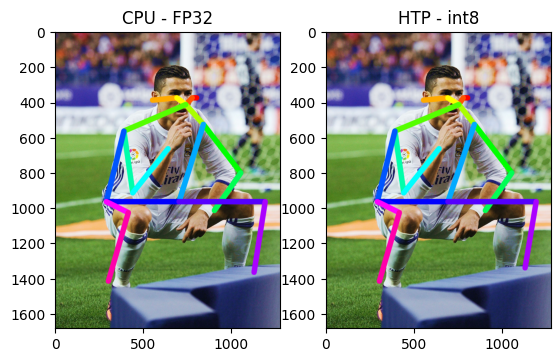

In [40]:
# From dlc output
image_pose = img.copy() # needs image in rgb

output = 0
pose_preds_CPU = 0
pose_preds = 0
with torch.no_grad():
    # # # compute output heatmap
    output_CPU = np.fromfile("output_cpu/Result_0/output.raw", np.float32).reshape(1,128,128,17)  #  (1,17,64,48)
    output_CPU = output_CPU.transpose(0,3,1,2)
    output_CPU = torch.from_numpy(output_CPU)
    
    output_HTP8 = np.fromfile("output_htp/Result_0/output.raw", np.float32)
    output_HTP8 = output_HTP8.reshape(1,128,128,17)  #  (1,17,64,48)
    
    output_HTP8 = output_HTP8.transpose(0,3,1,2)
    output_HTP8 = torch.from_numpy(output_HTP8)


    pose_preds_CPU, _ = get_final_preds(
        cfg,
        output_CPU.clone().cpu().numpy(),
        np.asarray([center]),
        np.asarray([scale]))

    pose_preds_HTP8, _ = get_final_preds(
        cfg,
        output_HTP8.clone().cpu().numpy(),
        np.asarray([center]),
        np.asarray([scale]))

##DRAW
image_pose_CPU = img.copy()
for key_pt in pose_preds_CPU:
    draw_pose(key_pt,image_pose_CPU) # draw the poses

##DRAW
image_pose_HTP8 = img.copy()
for key_pt in pose_preds_HTP8:
    draw_pose(key_pt,image_pose_HTP8) # draw the poses
    
f, axarr = plt.subplots(nrows=1,ncols=2)
plt.sca(axarr[0]); 
plt.imshow(image_pose_CPU); plt.title('CPU - FP32')
plt.sca(axarr[1]); 
plt.imshow(image_pose_HTP8); plt.title('HTP - int8')

In [41]:
%%cmd 
qnn-profile-viewer --input_log output_htp/qnn-profiling-data_0.log

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\Pose_Estimation\HRNet-Human-Pose-Estimation>qnn-profile-viewer --input_log output_htp/qnn-profiling-data_0.log
Log File Created: Sat Jun 15 02:00:00 2024
Time Scale: 1e-06
Epoch Timestamp: 1718442000967976 Steady Clock Timestamp: 915008302420
Generated using: 
qnn-profile-viewer v2.21.0.240401120655_85612
qnn-net-run        v2.21.0.240401120655_85612
Backend            v2.21.0.240401120655_85612

Qnn Init/Prepare/Finalize/De-Init/Execute/Lib-Load Statistics:
------------------------------------------------------------
Init Stats:
-----------
    NetRun: 31209 us
    Backend (RPC (load binary) time): 20267 us
    Backend (QNN accelerator (load binary) time): 19722 us
    Backend (Accelerator (load binary) time): 17761 us
    Backend (QNN (load binary) time): 31191 us

Compose Graphs Stats:
--------------
    NetRun: 0 us

Finalize Stats:
---------------

De-Init Stats: